In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = pd.read_csv('../Data/struct/features_main_struct.csv', keep_default_na=False)
temporal_df = pd.read_csv('../Data/struct/features_test_temporal_struct.csv', keep_default_na=False)
obfuscated_df = pd.read_csv('../Data/struct/features_test_obfuscated_struct.csv', keep_default_na=False)
notinject_df = pd.read_csv('../Data/struct/features_test_notinject_struct.csv', keep_default_na=False)


In [5]:
id_cols = ['uid', 'split', 'label', 'source', 'attack_type']
feature_cols = [c for c in df.columns if c not in id_cols]

In [6]:
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']

X_train, y_train = train_df[feature_cols], train_df['label']
X_val, y_val = val_df[feature_cols], val_df['label']

In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [8]:
train_preds = model.predict(X_train)
print("--- Training Set ---")
print("Accuracy:", accuracy_score(y_train, train_preds))
print(classification_report(y_train, train_preds))

--- Training Set ---
Accuracy: 0.9456093003944364
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      6052
           1       0.98      0.87      0.92      3582

    accuracy                           0.95      9634
   macro avg       0.95      0.93      0.94      9634
weighted avg       0.95      0.95      0.94      9634



In [9]:
val_preds = model.predict(X_val)
print("--- Validation Set ---")
print("Accuracy:", accuracy_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

--- Validation Set ---
Accuracy: 0.9190451478982875
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1210
           1       0.95      0.82      0.88       717

    accuracy                           0.92      1927
   macro avg       0.93      0.90      0.91      1927
weighted avg       0.92      0.92      0.92      1927



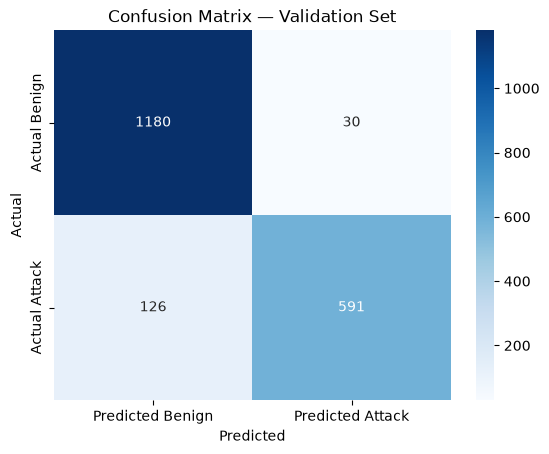

In [10]:
cm_val = confusion_matrix(y_val, val_preds)
plt.figure()
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Validation Set')
plt.show()

--- Temporal ---
Accuracy: 0.6948453608247422
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       308
           1       0.61      0.47      0.53       177

    accuracy                           0.69       485
   macro avg       0.67      0.65      0.65       485
weighted avg       0.68      0.69      0.68       485



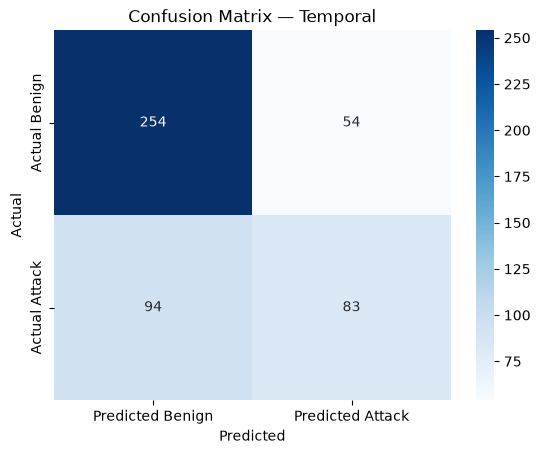

--- Obfuscated ---
Accuracy: 0.8561111111111112
              precision    recall  f1-score   support

           0       0.78      0.98      0.87       900
           1       0.98      0.73      0.84       900

    accuracy                           0.86      1800
   macro avg       0.88      0.86      0.85      1800
weighted avg       0.88      0.86      0.85      1800



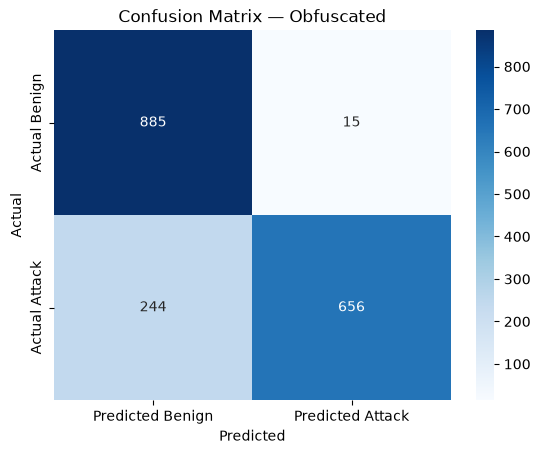

--- Notinject ---
Accuracy: 0.8820058997050148
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       339
           1       0.00      0.00      0.00         0

    accuracy                           0.88       339
   macro avg       0.50      0.44      0.47       339
weighted avg       1.00      0.88      0.94       339



c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

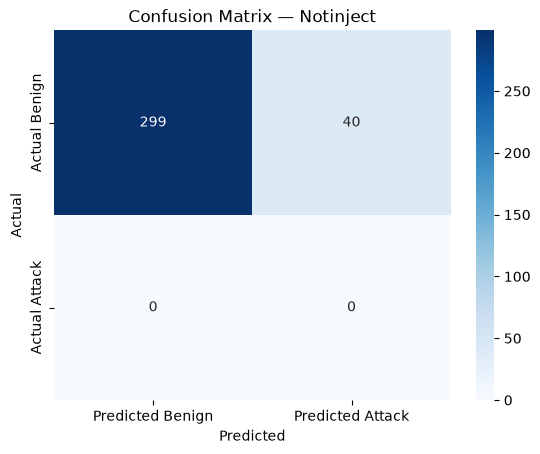

In [11]:
def evaluate(df_test, name):
    X = df_test[feature_cols]
    y = df_test['label']
    preds = model.predict(X)

    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y, preds))
    print(classification_report(y, preds))

    cm = confusion_matrix(y, preds, labels=[0, 1])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Benign', 'Predicted Attack'],
                yticklabels=['Actual Benign', 'Actual Attack'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return df_test, preds


temp_df, temp_preds = evaluate(temporal_df, 'Temporal')
obf_df, obf_preds = evaluate(obfuscated_df, 'Obfuscated')
notinj_df, notinj_preds = evaluate(notinject_df, 'Notinject')